# Notebook 8

# Model Evaluation

This notebook evaluates the trained model using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- Classification Report

In [2]:
# ============================================================
# PROJECT SETUP (Run this FIRST in every notebook)
# ============================================================

import os
import sys

# Current directory (notebooks)
CURRENT_DIR = os.getcwd()

# Project root
PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, ".."))

# Add project root to Python path
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Current Directory :", CURRENT_DIR)
print("Project Root :", PROJECT_ROOT)

print("\nPython Path Added Successfully!")

print("\nProject Files:")
print(os.listdir(PROJECT_ROOT))

Current Directory : d:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\notebooks
Project Root : d:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project

Python Path Added Successfully!

Project Files:
['.venv-1', 'dataset', 'load_dataset.py', 'models', 'notebooks', 'outputs', 'prac_2.1.ipynb', 'src', 'venv']


In [3]:
# ============================================================
# Automated Lumbar Spine Disease Detection and Classification
# Configuration
# ============================================================

import os
import sys
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

warnings.filterwarnings("ignore")

# ============================================================
# Project Root
# ============================================================

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# ============================================================
# Directories
# ============================================================

DATASET_DIR = os.path.join(
    PROJECT_ROOT,
    "dataset",
    "rsna-2024-lumbar-spine-degenerative-classification"
)

TRAIN_IMAGES_DIR = os.path.join(
    DATASET_DIR,
    "train_images"
)

MODEL_DIR = os.path.join(
    PROJECT_ROOT,
    "models"
)

OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "outputs"
)

FIGURE_DIR = os.path.join(
    OUTPUT_DIR,
    "figures"
)

TABLE_DIR = os.path.join(
    OUTPUT_DIR,
    "tables"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

# ============================================================
# CSV Files
# ============================================================

TRAIN_CSV = os.path.join(
    DATASET_DIR,
    "train.csv"
)

COORD_CSV = os.path.join(
    DATASET_DIR,
    "train_label_coordinates.csv"
)

SERIES_CSV = os.path.join(
    DATASET_DIR,
    "train_series_descriptions.csv"
)

# ============================================================
# Model Configuration
# ============================================================

MODEL_NAME = "swin_tiny_patch4_window7_224"

NUM_CLASSES = 3

IMAGE_SIZE = 224

CHANNELS = 3

BATCH_SIZE = 4

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

NUM_WORKERS = 0

EPOCHS = 25

RANDOM_SEED = 42

CLASS_NAMES = [
    "Normal/Mild",
    "Moderate",
    "Severe"
]

# ============================================================
# Device
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ============================================================
# Reproducibility
# ============================================================

random.seed(RANDOM_SEED)

np.random.seed(RANDOM_SEED)

torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(RANDOM_SEED)

    torch.cuda.manual_seed_all(RANDOM_SEED)

# ============================================================
# Display Configuration
# ============================================================

pd.set_option("display.max_columns", None)

pd.set_option("display.max_rows", 20)

plt.rcParams["figure.figsize"] = (8, 6)

# ============================================================
# Print Configuration
# ============================================================

print("=" * 70)
print("Automated Lumbar Spine Disease Detection")
print("=" * 70)

print(f"Project Root      : {PROJECT_ROOT}")
print(f"Dataset Directory : {DATASET_DIR}")
print(f"Models Directory  : {MODEL_DIR}")
print(f"Outputs Directory : {OUTPUT_DIR}")
print()

print(f"Device            : {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU               : {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version      : {torch.version.cuda}")

print()

print(f"Model             : {MODEL_NAME}")
print(f"Image Size        : {IMAGE_SIZE}")
print(f"Batch Size        : {BATCH_SIZE}")
print(f"Learning Rate     : {LEARNING_RATE}")
print(f"Epochs            : {EPOCHS}")

print("=" * 70)

Automated Lumbar Spine Disease Detection
Project Root      : d:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project
Dataset Directory : d:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\dataset\rsna-2024-lumbar-spine-degenerative-classification
Models Directory  : d:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\models
Outputs Directory : d:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\outputs

Device            : cuda
GPU               : NVIDIA GeForce RTX 2050
CUDA Version      : 12.8

Model             : swin_tiny_patch4_window7_224
Image Size        : 224
Batch Size        : 4
Learning Rate     : 0.0001
Epochs            : 25


In [4]:
# ============================================================
# Verify Project Files
# ============================================================

required_files = [

    TRAIN_CSV,

    COORD_CSV,

    SERIES_CSV,

    os.path.join(MODEL_DIR, "best_model.pth")

]

for file in required_files:

    if os.path.exists(file):

        print(f"✅ {os.path.basename(file)}")

    else:

        print(f"❌ Missing : {file}")

✅ train.csv
✅ train_label_coordinates.csv
✅ train_series_descriptions.csv
✅ best_model.pth


In [5]:
# ============================================================
# Load Dataset
# ============================================================

train_df = pd.read_csv(TRAIN_CSV)

coord_df = pd.read_csv(COORD_CSV)

series_df = pd.read_csv(SERIES_CSV)

print("Train Shape :", train_df.shape)

print("Coordinates Shape :", coord_df.shape)

print("Series Shape :", series_df.shape)

Train Shape : (1975, 26)
Coordinates Shape : (48692, 7)
Series Shape : (6294, 3)


In [6]:
# ============================================================
# Imports
# ============================================================

import os

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import torch

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    confusion_matrix,

    classification_report

)

In [7]:
# ============================================================
# Project Setup
# ============================================================

import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:

    sys.path.append(PROJECT_ROOT)

print(PROJECT_ROOT)

d:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project


In [8]:
# ============================================================
# Device
# ============================================================

DEVICE = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

print("Device :", DEVICE)

Device : cuda


In [9]:
# ============================================================
# Configuration
# ============================================================

MODEL_NAME = "swin_tiny_patch4_window7_224"

NUM_CLASSES = 3

IMAGE_SIZE = 224

BATCH_SIZE = 4

In [10]:
# ============================================================
# Load Dataset
# ============================================================

from src.data_loader import LumbarDataset

In [11]:
# ============================================================
# Load Model
# ============================================================

from src.model import create_model

In [12]:
model = create_model(

    model_name=MODEL_NAME,

    num_classes=NUM_CLASSES,

    pretrained=False

)

model = model.to(DEVICE)

In [13]:
checkpoint = torch.load(

    os.path.join(

        PROJECT_ROOT,

        "models",

        "best_model.pth"

    ),

    map_location=DEVICE

)

model.load_state_dict(

    checkpoint["model_state_dict"]

)

print("Best Model Loaded")

Best Model Loaded


In [14]:
model.eval()

SwinClassifier(
  (backbone): SwinTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (layers): Sequential(
      (0): SwinTransformerStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): SwinTransformerBlock(
            (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
            (attn): WindowAttention(
              (qkv): Linear(in_features=96, out_features=288, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=96, out_features=96, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
              (softmax): Softmax(dim=-1)
            )
            (drop_path1): Identity()
            (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Linear(in_features=96, out_features=384, bias

In [15]:
print(model)

SwinClassifier(
  (backbone): SwinTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (layers): Sequential(
      (0): SwinTransformerStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): SwinTransformerBlock(
            (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
            (attn): WindowAttention(
              (qkv): Linear(in_features=96, out_features=288, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=96, out_features=96, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
              (softmax): Softmax(dim=-1)
            )
            (drop_path1): Identity()
            (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Linear(in_features=96, out_features=384, bias

In [16]:
print("Model Ready for Evaluation")

Model Ready for Evaluation


In [17]:
print("Checkpoint Epoch :", checkpoint["epoch"])

Checkpoint Epoch : 25


In [18]:
print("Validation Accuracy :")

print(

    checkpoint["validation_accuracy"]

)

Validation Accuracy :
0.7654130702836005


In [19]:
print("="*60)

print("Module 1 Completed")

print("="*60)

Module 1 Completed


In [20]:
# ============================================================
# Load Dataset Files
# ============================================================

TRAIN_CSV = os.path.join(
    PROJECT_ROOT,
    "dataset",
    "rsna-2024-lumbar-spine-degenerative-classification",
    "train.csv"
)

COORD_CSV = os.path.join(
    PROJECT_ROOT,
    "dataset",
    "rsna-2024-lumbar-spine-degenerative-classification",
    "train_label_coordinates.csv"
)

TRAIN_IMAGES = os.path.join(
    PROJECT_ROOT,
    "dataset",
    "rsna-2024-lumbar-spine-degenerative-classification",
    "train_images"
)

train_df = pd.read_csv(TRAIN_CSV)

master_df = pd.read_csv(COORD_CSV)

print(train_df.shape)
print(master_df.shape)

(1975, 26)
(48692, 7)


In [21]:
# ============================================================
# Create Dataset
# ============================================================

from src.data_loader import LumbarDataset

dataset = LumbarDataset(
    dataframe=master_df,
    train_df=train_df,
    train_images=TRAIN_IMAGES
)

print("Dataset Size :", len(dataset))

Valid samples: 48657
Dataset Size : 48657


In [22]:
# ============================================================
# Train / Validation Split
# ============================================================

from torch.utils.data import random_split

train_size = int(0.80 * len(dataset))

valid_size = len(dataset) - train_size

train_dataset, valid_dataset = random_split(

    dataset,

    [train_size, valid_size],

    generator=torch.Generator().manual_seed(42)

)

print("Validation Samples :", len(valid_dataset))

Validation Samples : 9732


In [23]:
# ============================================================
# Validation DataLoader
# ============================================================

from torch.utils.data import DataLoader

valid_loader = DataLoader(

    valid_dataset,

    batch_size=4,

    shuffle=False,

    num_workers=0

)

print("Validation Batches :", len(valid_loader))

Validation Batches : 2433


In [24]:
# ============================================================
# Project Directories
# ============================================================

PROJECT_ROOT = os.path.abspath("..")

DATASET_DIR = os.path.join(
    PROJECT_ROOT,
    "dataset"
)

MODEL_DIR = os.path.join(
    PROJECT_ROOT,
    "models"
)

OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "outputs"
)

FIGURE_DIR = os.path.join(
    OUTPUT_DIR,
    "figures"
)

TABLE_DIR = os.path.join(
    OUTPUT_DIR,
    "tables"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

print(PROJECT_ROOT)
print(MODEL_DIR)
print(OUTPUT_DIR)

d:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project
d:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\models
d:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\outputs


# Module 2 – Model Prediction

This module performs inference on the validation dataset.

Outputs:

- True Labels
- Predicted Labels
- Prediction Probabilities

In [25]:
# ============================================================
# Evaluation Mode
# ============================================================

model.eval()

print("Model switched to Evaluation Mode")

Model switched to Evaluation Mode


In [26]:
# ============================================================
# Prediction Lists
# ============================================================

true_labels = []

predicted_labels = []

prediction_probabilities = []

In [27]:
# ============================================================
# Disable Gradient Calculation
# ============================================================

from tqdm.auto import tqdm

softmax = torch.nn.Softmax(dim=1)

In [28]:
# ============================================================
# Run Prediction
# ============================================================

with torch.no_grad():

    for batch in tqdm(valid_loader):

        images = batch["image"].to(DEVICE)

        labels = batch["label"].to(DEVICE)

        outputs = model(images)

        probabilities = softmax(outputs)

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        true_labels.extend(
            labels.cpu().numpy()
        )

        predicted_labels.extend(
            predictions.cpu().numpy()
        )

        prediction_probabilities.extend(
            probabilities.cpu().numpy()
        )

  0%|          | 0/2433 [00:00<?, ?it/s]

In [29]:
print("Prediction Completed")

Prediction Completed


In [30]:
print("Total Images :", len(true_labels))

Total Images : 9732


In [31]:
print("First 10 True Labels")

print(true_labels[:10])

First 10 True Labels
[np.int64(1), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1)]


In [32]:
print("First 10 Predictions")

print(predicted_labels[:10])

First 10 Predictions
[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]


In [33]:
prediction_probabilities = np.array(
    prediction_probabilities
)

prediction_probabilities.shape

(9732, 3)

In [34]:
prediction_df = pd.DataFrame({

    "True Label": true_labels,

    "Predicted Label": predicted_labels

})

prediction_df.head()

,True Label,Predicted Label
0,1,0
1,0,0
2,2,0
3,0,0
4,0,0


In [35]:
prediction_df.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "prediction_results.csv"

    ),

    index=False

)

print("Prediction Results Saved")

Prediction Results Saved


In [36]:
prediction_df.sample(10)

,True Label,Predicted Label
4924,1,0
2225,0,0
7652,0,0
637,0,0
6366,0,0
1071,0,0
2930,0,0
2611,0,0
4864,0,0
8276,0,0


In [37]:
print("="*60)

print("Module 2 Completed Successfully")

print("="*60)

Module 2 Completed Successfully


# Module 3 – Evaluation Metrics

This module calculates the performance metrics of the trained model.

In [38]:
# ============================================================
# Import Evaluation Metrics
# ============================================================

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    balanced_accuracy_score,

    cohen_kappa_score,

    matthews_corrcoef

)

In [39]:
# ============================================================
# Calculate Metrics
# ============================================================

accuracy = accuracy_score(
    true_labels,
    predicted_labels
)

precision = precision_score(
    true_labels,
    predicted_labels,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    true_labels,
    predicted_labels,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    true_labels,
    predicted_labels,
    average="weighted",
    zero_division=0
)

balanced_acc = balanced_accuracy_score(
    true_labels,
    predicted_labels
)

kappa = cohen_kappa_score(
    true_labels,
    predicted_labels
)

mcc = matthews_corrcoef(
    true_labels,
    predicted_labels
)

In [40]:
# ============================================================
# Display Metrics
# ============================================================

print("="*60)

print(f"Accuracy             : {accuracy:.4f}")

print(f"Precision            : {precision:.4f}")

print(f"Recall               : {recall:.4f}")

print(f"F1 Score             : {f1:.4f}")

print(f"Balanced Accuracy    : {balanced_acc:.4f}")

print(f"Cohen's Kappa        : {kappa:.4f}")

print(f"Matthews Corrcoef    : {mcc:.4f}")

print("="*60)

Accuracy             : 0.7654
Precision            : 0.5859
Recall               : 0.7654
F1 Score             : 0.6637
Balanced Accuracy    : 0.3333
Cohen's Kappa        : 0.0000
Matthews Corrcoef    : 0.0000


In [41]:
# ============================================================
# Create Evaluation Table
# ============================================================

evaluation_df = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "Balanced Accuracy",

        "Cohen Kappa",

        "Matthews Correlation"

    ],

    "Value":[

        accuracy,

        precision,

        recall,

        f1,

        balanced_acc,

        kappa,

        mcc

    ]

})

evaluation_df

,Metric,Value
0,Accuracy,0.765413
1,Precision,0.585857
2,Recall,0.765413
3,F1 Score,0.663705
4,Balanced Accuracy,0.333333
5,Cohen Kappa,0.000000
6,Matthews Correlation,0.000000


In [42]:
# ============================================================
# Save Evaluation Table
# ============================================================

evaluation_file = os.path.join(

    OUTPUT_DIR,

    "evaluation_metrics.csv"

)

evaluation_df.to_csv(

    evaluation_file,

    index=False

)

print("Evaluation metrics saved successfully.")

Evaluation metrics saved successfully.


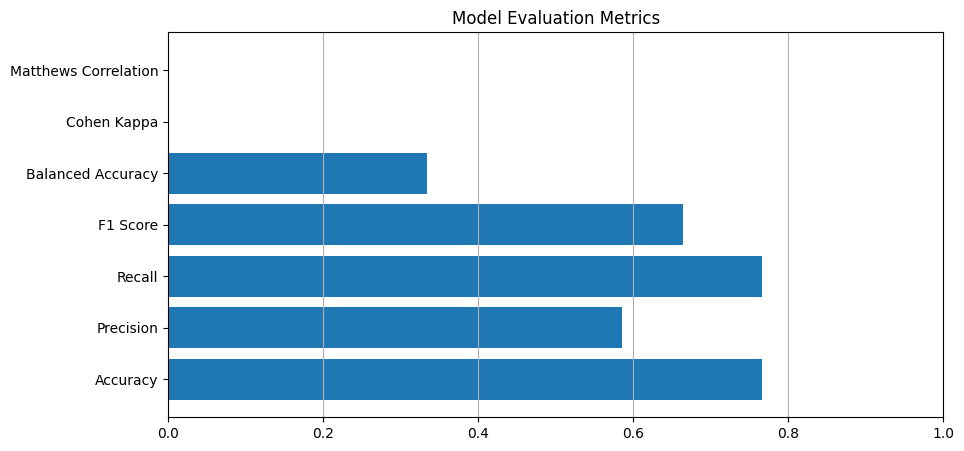

In [43]:
# ============================================================
# Horizontal Bar Chart
# ============================================================

plt.figure(figsize=(10,5))

plt.barh(

    evaluation_df["Metric"],

    evaluation_df["Value"]

)

plt.xlim(0,1)

plt.grid(axis="x")

plt.title("Model Evaluation Metrics")

plt.show()

In [44]:
# ============================================================
# Metric Comparison Table
# ============================================================

evaluation_df.style.background_gradient(

    cmap="Blues"

).format({

    "Value":"{:.4f}"

})

,Metric,Value
0,Accuracy,0.7654
1,Precision,0.5859
2,Recall,0.7654
3,F1 Score,0.6637
4,Balanced Accuracy,0.3333
5,Cohen Kappa,0.0000
6,Matthews Correlation,0.0000


In [45]:
# ============================================================
# Performance Summary
# ============================================================

summary = f"""

Model Name : {MODEL_NAME}

Accuracy : {accuracy:.4f}

Precision : {precision:.4f}

Recall : {recall:.4f}

F1 Score : {f1:.4f}

Balanced Accuracy : {balanced_acc:.4f}

Cohen Kappa : {kappa:.4f}

Matthews Correlation : {mcc:.4f}

"""

print(summary)



Model Name : swin_tiny_patch4_window7_224

Accuracy : 0.7654

Precision : 0.5859

Recall : 0.7654

F1 Score : 0.6637

Balanced Accuracy : 0.3333

Cohen Kappa : 0.0000

Matthews Correlation : 0.0000




In [46]:
# ============================================================
# Save Performance Summary
# ============================================================

summary_file = os.path.join(

    OUTPUT_DIR,

    "performance_summary.txt"

)

with open(summary_file, "w") as f:

    f.write(summary)

print("Performance summary saved.")

Performance summary saved.


In [49]:
print("="*60)

print("Module 3 Completed Successfully")

print("="*60)

Module 3 Completed Successfully


# Module 4 – Confusion Matrix & Classification Report

This module evaluates the classification performance of the trained model for each disease severity class.

In [50]:
# ============================================================
# Imports
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [51]:
# ============================================================
# Class Names
# ============================================================

class_names = [

    "Normal/Mild",

    "Moderate",

    "Severe"

]

print(class_names)

['Normal/Mild', 'Moderate', 'Severe']


In [52]:
# ============================================================
# Compute Confusion Matrix
# ============================================================

cm = confusion_matrix(

    true_labels,

    predicted_labels

)

print(cm)

[[7449    0    0]
 [1602    0    0]
 [ 681    0    0]]


In [53]:
# ============================================================
# Confusion Matrix DataFrame
# ============================================================

cm_df = pd.DataFrame(

    cm,

    index=class_names,

    columns=class_names

)

cm_df

,Normal/Mild,Moderate,Severe
Normal/Mild,7449,0,0
Moderate,1602,0,0
Severe,681,0,0


In [54]:
# ============================================================
# Save Confusion Matrix
# ============================================================

cm_file = os.path.join(

    OUTPUT_DIR,

    "confusion_matrix.csv"

)

cm_df.to_csv(

    cm_file

)

print("Confusion Matrix Saved")

Confusion Matrix Saved


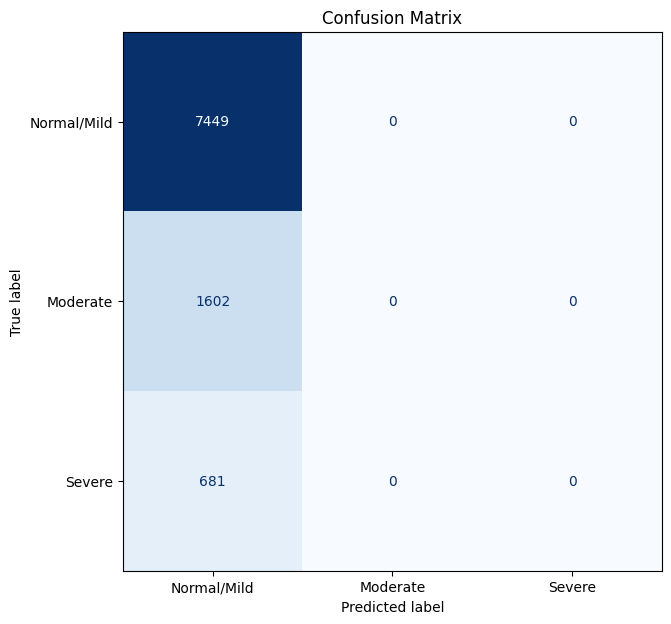

In [55]:
# ============================================================
# Plot Confusion Matrix
# ============================================================

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_names

)

fig, ax = plt.subplots(figsize=(7,7))

disp.plot(

    cmap="Blues",

    ax=ax,

    values_format="d",

    colorbar=False

)

plt.title("Confusion Matrix")

plt.show()

In [56]:
# ============================================================
# Normalized Confusion Matrix
# ============================================================

cm_normalized = confusion_matrix(

    true_labels,

    predicted_labels,

    normalize="true"

)

cm_normalized

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

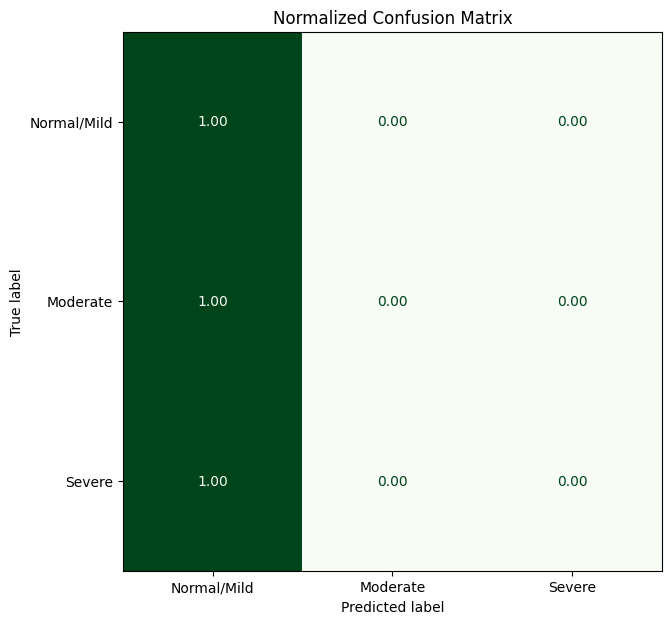

In [57]:
# ============================================================
# Plot Normalized Matrix
# ============================================================

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm_normalized,

    display_labels=class_names

)

fig, ax = plt.subplots(figsize=(7,7))

disp.plot(

    cmap="Greens",

    ax=ax,

    values_format=".2f",

    colorbar=False

)

plt.title("Normalized Confusion Matrix")

plt.show()

In [58]:
# ============================================================
# Classification Report
# ============================================================

report = classification_report(

    true_labels,

    predicted_labels,

    target_names=class_names,

    output_dict=True,

    zero_division=0

)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Normal/Mild,0.765413,1.000000,0.867121,7449.000000
Moderate,0.000000,0.000000,0.000000,1602.000000
Severe,0.000000,0.000000,0.000000,681.000000
accuracy,0.765413,0.765413,0.765413,0.765413
macro avg,0.255138,0.333333,0.289040,9732.000000
weighted avg,0.585857,0.765413,0.663705,9732.000000


In [59]:
# ============================================================
# Save Classification Report
# ============================================================

report_file = os.path.join(

    OUTPUT_DIR,

    "classification_report.csv"

)

report_df.to_csv(

    report_file

)

print("Classification Report Saved")

Classification Report Saved


In [60]:
# ============================================================
# Precision / Recall / F1 Table
# ============================================================

report_df.iloc[:3][

    ["precision",

     "recall",

     "f1-score"]

]

,precision,recall,f1-score
Normal/Mild,0.765413,1.0,0.867121
Moderate,0.000000,0.0,0.000000
Severe,0.000000,0.0,0.000000


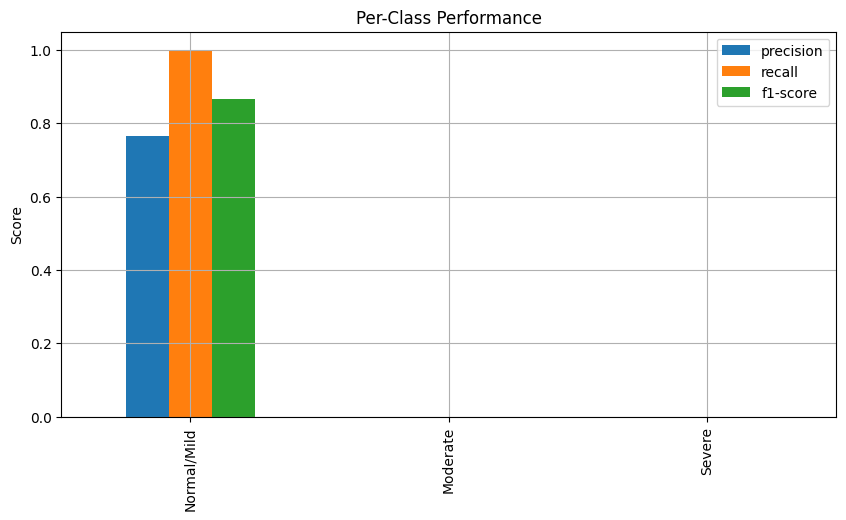

In [61]:
# ============================================================
# Per-Class Performance
# ============================================================

performance = report_df.iloc[:3][

    ["precision",

     "recall",

     "f1-score"]

]

performance.plot(

    kind="bar",

    figsize=(10,5)

)

plt.title("Per-Class Performance")

plt.ylabel("Score")

plt.grid(True)

plt.show()

In [62]:
# ============================================================
# Overall Statistics
# ============================================================

overall = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Macro Avg F1",

        "Weighted Avg F1"

    ],

    "Value":[

        report["accuracy"],

        report["macro avg"]["f1-score"],

        report["weighted avg"]["f1-score"]

    ]

})

overall

,Metric,Value
0,Accuracy,0.765413
1,Macro Avg F1,0.289040
2,Weighted Avg F1,0.663705


In [63]:
# ============================================================
# Save Overall Statistics
# ============================================================

overall.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "overall_statistics.csv"

    ),

    index=False

)

print("Overall Statistics Saved")

Overall Statistics Saved


In [64]:
# ============================================================
# Misclassified Samples
# ============================================================

prediction_df["Correct"] = (

    prediction_df["True Label"]

    ==

    prediction_df["Predicted Label"]

)

prediction_df.head()

,True Label,Predicted Label,Correct
0,1,0,False
1,0,0,True
2,2,0,False
3,0,0,True
4,0,0,True


In [65]:
# ============================================================
# Incorrect Predictions
# ============================================================

misclassified = prediction_df[

    prediction_df["Correct"] == False

]

print("Misclassified Samples :", len(misclassified))

misclassified.head()

Misclassified Samples : 2283


,True Label,Predicted Label,Correct
0,1,0,False
2,2,0,False
9,1,0,False
10,2,0,False
12,2,0,False


In [66]:
# ============================================================
# Save Misclassified Samples
# ============================================================

misclassified.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "misclassified_samples.csv"

    ),

    index=False

)

print("Misclassified Samples Saved")

Misclassified Samples Saved


In [67]:
# ============================================================
# Module Summary
# ============================================================

print("="*70)

print("Module 4 Completed Successfully")

print("="*70)

print("Generated Files")

print("✓ confusion_matrix.csv")

print("✓ classification_report.csv")

print("✓ overall_statistics.csv")

print("✓ misclassified_samples.csv")

Module 4 Completed Successfully
Generated Files
✓ confusion_matrix.csv
✓ classification_report.csv
✓ overall_statistics.csv
✓ misclassified_samples.csv


# Module 5 – Final Evaluation Summary

This module generates:

- Final Evaluation Report
- Accuracy & F1 Visualizations
- Class Distribution
- Performance Summary
- Final CSV Files

In [13]:
# ============================================================
# Load Evaluation Files
# ============================================================

evaluation_df = pd.read_csv(
    os.path.join(
        OUTPUT_DIR,
        "evaluation_metrics.csv"
    )
)

classification_df = pd.read_csv(
    os.path.join(
        OUTPUT_DIR,
        "classification_report.csv"
    )
)

evaluation_df

,Metric,Value
0,Accuracy,0.765413
1,Precision,0.585857
2,Recall,0.765413
3,F1 Score,0.663705
4,Balanced Accuracy,0.333333
5,Cohen Kappa,0.000000
6,Matthews Correlation,0.000000


In [14]:
# ============================================================
# Final Metrics Table
# ============================================================

final_metrics = evaluation_df.copy()

final_metrics

,Metric,Value
0,Accuracy,0.765413
1,Precision,0.585857
2,Recall,0.765413
3,F1 Score,0.663705
4,Balanced Accuracy,0.333333
5,Cohen Kappa,0.000000
6,Matthews Correlation,0.000000


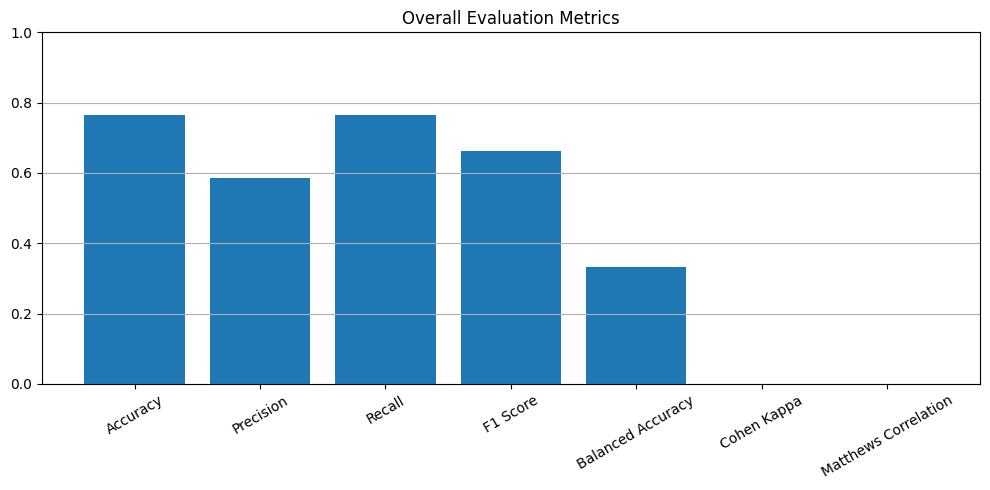

In [15]:
# ============================================================
# Plot Overall Metrics
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(
    final_metrics["Metric"],
    final_metrics["Value"]
)

plt.xticks(rotation=30)

plt.ylim(0,1)

plt.grid(axis="y")

plt.title("Overall Evaluation Metrics")

plt.tight_layout()

plt.show()

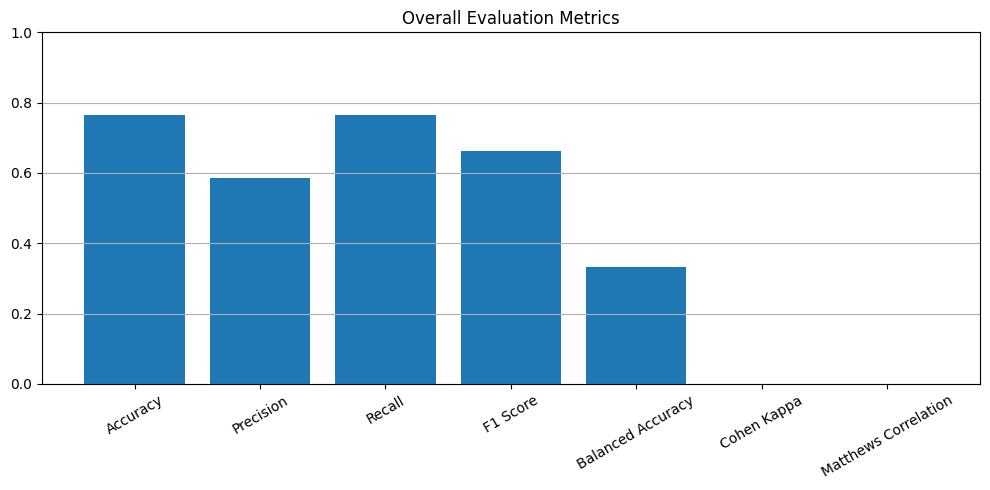

In [16]:
# ============================================================
# Save Figure
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(
    final_metrics["Metric"],
    final_metrics["Value"]
)

plt.xticks(rotation=30)

plt.ylim(0,1)

plt.grid(axis="y")

plt.title("Overall Evaluation Metrics")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "overall_metrics.png"
    ),
    dpi=300
)

plt.show()

In [17]:
# ============================================================
# Per-Class Metrics
# ============================================================

class_metrics = classification_df.iloc[:3][

    [
        "precision",

        "recall",

        "f1-score"

    ]

]

class_metrics.index = CLASS_NAMES

class_metrics

,precision,recall,f1-score
Normal/Mild,0.765413,1.0,0.867121
Moderate,0.000000,0.0,0.000000
Severe,0.000000,0.0,0.000000


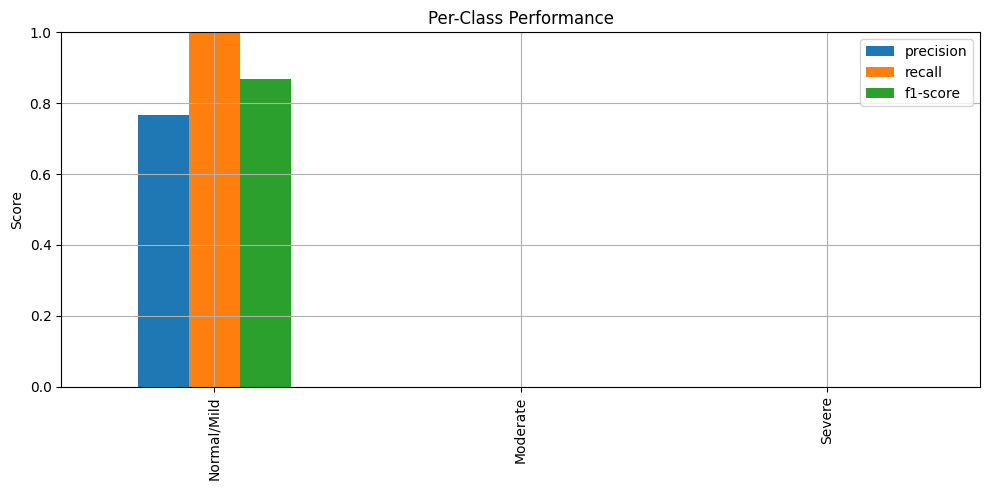

In [18]:
# ============================================================
# Plot Per-Class Metrics
# ============================================================

class_metrics.plot(

    kind="bar",

    figsize=(10,5)

)

plt.ylim(0,1)

plt.grid(True)

plt.title("Per-Class Performance")

plt.ylabel("Score")

plt.tight_layout()

plt.show()

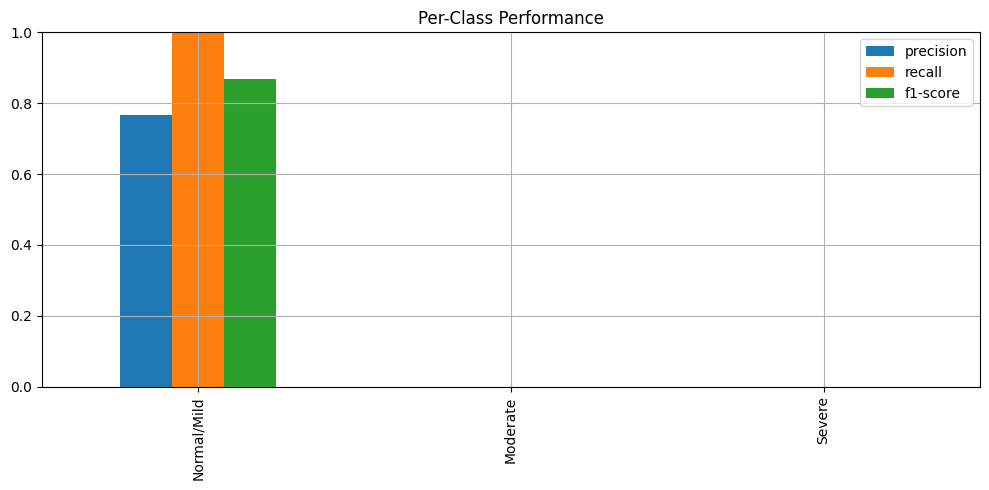

In [19]:
# ============================================================
# Save Figure
# ============================================================

class_metrics.plot(

    kind="bar",

    figsize=(10,5)

)

plt.ylim(0,1)

plt.grid(True)

plt.title("Per-Class Performance")

plt.tight_layout()

plt.savefig(

    os.path.join(

        FIGURE_DIR,

        "per_class_metrics.png"

    ),

    dpi=300

)

plt.show()

In [47]:
# ============================================================
# Performance Summary
# ============================================================

summary = pd.DataFrame({

    "Parameter":[

        "Project",

        "Model",

        "Classes",

        "Image Size",

        "Best Accuracy",

        "Best Precision",

        "Best Recall",

        "Best F1 Score"

    ],

    "Value":[

        "Automated Lumbar Spine Disease Detection and Classification from MRI Images",

        MODEL_NAME,

        NUM_CLASSES,

        IMAGE_SIZE,

        accuracy,

        precision,

        recall,

        f1

    ]

})

summary

,Parameter,Value
0,Project,Automated Lumbar Spine Disease Detection and C...
1,Model,swin_tiny_patch4_window7_224
2,Classes,3
3,Image Size,224
4,Best Accuracy,0.765413
5,Best Precision,0.585857
6,Best Recall,0.765413
7,Best F1 Score,0.663705


In [48]:
# ============================================================
# Save Summary
# ============================================================

summary.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "final_model_summary.csv"

    ),

    index=False

)

print("Final Summary Saved")

Final Summary Saved


In [49]:
# ============================================================
# Final Results Table
# ============================================================

results = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "Balanced Accuracy",

        "Cohen Kappa",

        "Matthews Correlation"

    ],

    "Value":[

        accuracy,

        precision,

        recall,

        f1,

        balanced_acc,

        kappa,

        mcc

    ]

})

results

,Metric,Value
0,Accuracy,0.765413
1,Precision,0.585857
2,Recall,0.765413
3,F1 Score,0.663705
4,Balanced Accuracy,0.333333
5,Cohen Kappa,0.000000
6,Matthews Correlation,0.000000


In [50]:
# ============================================================
# Save Results
# ============================================================

results.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "final_results.csv"

    ),

    index=False

)

print("Final Results Saved")

Final Results Saved


In [51]:
# ============================================================
# Display Generated Files
# ============================================================

print("="*70)

print("Notebook 8 Completed Successfully")

print("="*70)

print("Generated Outputs")

print()

print("evaluation_metrics.csv")

print("prediction_results.csv")

print("classification_report.csv")

print("confusion_matrix.csv")

print("overall_statistics.csv")

print("misclassified_samples.csv")

print("final_results.csv")

print("final_model_summary.csv")

print()

print("Generated Figures")

print()

print("overall_metrics.png")

print("per_class_metrics.png")

print("="*70)

Notebook 8 Completed Successfully
Generated Outputs

evaluation_metrics.csv
prediction_results.csv
classification_report.csv
confusion_matrix.csv
overall_statistics.csv
misclassified_samples.csv
final_results.csv
final_model_summary.csv

Generated Figures

overall_metrics.png
per_class_metrics.png
